In [2]:
import os, glob

import cytoflow as flow
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from flow_analysis_tools import flow_violin
from flow_analysis_tools.color_palettes import *

## Notebook and Experiment Setup

In [3]:
%matplotlib widget
matplotlib.rc('figure', dpi = 160)
plt.style.use('ggplot')

In [23]:
# DATA_DIR = ""
DATA_DIR = "/Users/alexandresathler/Library/CloudStorage/Box-Box/ARS_Working/Experiments/LX2-CRch-Const/260804-LX2-CRch-Const-Rep4/260824_LX2_CRchR4_Vp-d22_B2M-CD81_KD/CD81_Plate/analysis"
FCS_FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.fcs")))
YLIMITS = (0, 7)
BLUE_CHANNEL_NAME, BLUE_CHANNEL_TAG = "Construct", "mTagBFP2"
GREEN_CHANNEL_NAME, GREEN_CHANNEL_TAG = "Guide", "eGFP"
RED_CHANNEL_NAME, RED_CHANNEL_TAG = "Empty", "None"
YELLOW_CHANNEL_NAME, YELLOW_CHANNEL_TAG = "CD81", "PE"
FOCUS_CHANNEL = "YL1-A"
print('\n'.join([f"'{x}'" for x in FCS_FILES]))

'/Users/alexandresathler/Library/CloudStorage/Box-Box/ARS_Working/Experiments/LX2-CRch-Const/260804-LX2-CRch-Const-Rep4/260824_LX2_CRchR4_Vp-d22_B2M-CD81_KD/CD81_Plate/analysis/260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_LX2_Stained.fcs'
'/Users/alexandresathler/Library/CloudStorage/Box-Box/ARS_Working/Experiments/LX2-CRch-Const/260804-LX2-CRch-Const-Rep4/260824_LX2_CRchR4_Vp-d22_B2M-CD81_KD/CD81_Plate/analysis/260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_LX2_Unstained.fcs'
'/Users/alexandresathler/Library/CloudStorage/Box-Box/ARS_Working/Experiments/LX2-CRch-Const/260804-LX2-CRch-Const-Rep4/260824_LX2_CRchR4_Vp-d22_B2M-CD81_KD/CD81_Plate/analysis/260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_pARS001_sgDC01.fcs'
'/Users/alexandresathler/Library/CloudStorage/Box-Box/ARS_Working/Experiments/LX2-CRch-Const/260804-LX2-CRch-Const-Rep4/260824_LX2_CRchR4_Vp-d22_B2M-CD81_KD/CD81_Plate/analysis/260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_pARS001_sgNT.fcs'
'/Users/alexandresathler/Library/Cloud

## Import Setup
Expects file names to have paired identity.

Each construct (e.g. LX2, Cas9, Cas12, pARS001, pARS002) should have 1 or 2 corresponding "guides" (or downstream conditions) assigned to them. So:
- **_LX2_**: Stained & Unstained
- **_Cas9_**: sgNT and sgTargeting
- ...

In [7]:

CONSTRUCT_NAME_N_UNDERSCORE = 2

construct_names = {
    "zim3": "dCas9-ZIM3",
    "ZIM3": "dCas9-ZIM3",
    "ARS001": "dCas9-ZIM3",
    "pARS001": "dCas9-ZIM3",
    "pCH95": "H3t-D3L-dCas9",
    "pCH96": "H3t-D3L-dCas9-KOX1",
    "pCH97": "H3t-KOX1-D3L-dCas9",
    "HEK-CLTA": "HEK",
    "sgCLTA-1X": "sgCLTA",
    "sgCLTA-20X": "sgCLTA",
    "Mock": "LX2",
    "Ctrl": "Unstained",
    "LX-2": "LX2",
}

def get_construct_name(name):
    this_name = name.split("_")[-CONSTRUCT_NAME_N_UNDERSCORE]
    if this_name in construct_names.keys():
        return construct_names[this_name]
    return this_name

def get_guide_type(name):
    # if '_NT_' in name or '_nt_' in name:
    #     return "non-targeting"
    # else:
    #     return "targeting"
    if "_HEK_" in name: return "CLTA-"
    if "_HEK-CLTA_" in name: return "CLTA+"
    if "-1X" in name: return "1X"
    if "-20X" in name: return "20X"
    if "Mock" in name: return "LX-2"
    if "Parental" in name: return ""
    if "Unstained" in name: return "Ab-"
    if "Stained" in name: return "Ab+"
    if "sgNT" in name: return "NT"
    # if "Col1a1" in name: return "Col1a1"
    if "no1ary" in name: return "1°Ab-"
    if "Stained" in name: return "1°Ab+"
    if "w1ary" in name: return "1°Ab+"
    if "DC01" in name: return "CD81"
    if "sgDC01" in name: return "CD81"
    if "DC02" in name: return "B2M"
    if "sgDC02" in name: return "B2M"
    if "DC03" in name: return "Col1a1"
    if "sgDC03" in name: return "Col1a1"

In [8]:
CONSTRUCT_NAMES = [get_construct_name(fcs_file) for fcs_file in FCS_FILES]
GUIDE_NAMES = [get_guide_type(fcs_file) for fcs_file in FCS_FILES]
FCS_NAMES = [os.path.basename(x) for x in FCS_FILES]
max_fcs_len = max([len(x) for x in FCS_NAMES]) + 5
for fcs, const, guide in zip(FCS_NAMES, CONSTRUCT_NAMES, GUIDE_NAMES):
    print(f"{fcs + "".join([" "] * (max_fcs_len - len(fcs)))}{str(const):<30}{str(guide):<20}")

import_op = flow.ImportOp(
    conditions = {
        "Construct": "category",
        "Guide": "category"
    },
    tubes = [flow.Tube(file=fcs_file, conditions={
        "Construct": get_construct_name(fcs_file),
        "Guide": get_guide_type(fcs_file)
    }) for fcs_file in FCS_FILES],
    # channels = channel_names
)

try:
    ex = import_op.apply()
except ValueError as e:
    error_text = str(e)
    if error_text == "Categorical categories cannot be null":
        raise Exception(
            "Functions 'get_construct_name' or 'get_guide_type' likely are turning None or NoneType." + \
            "\n\t   This is typically because a construct or guide name case isn't properly handled."
        )
    else:
        raise e

260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_LX2_Stained.fcs        LX2                           Ab+                 
260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_LX2_Unstained.fcs      LX2                           Ab-                 
260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_pARS001_sgDC01.fcs     dCas9-ZIM3                    CD81                
260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_pARS001_sgNT.fcs       dCas9-ZIM3                    NT                  
260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_pCH95_sgDC01.fcs       H3t-D3L-dCas9                 CD81                
260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_pCH95_sgNT.fcs         H3t-D3L-dCas9                 NT                  
260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_pCH96_sgDC01.fcs       H3t-D3L-dCas9-KOX1            CD81                
260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_pCH96_sgNT.fcs         H3t-D3L-dCas9-KOX1            NT                  
260824_CRchR4_LX2_Live_CD81-PE_KD_Experiment_pCH

## Select Cells

In [9]:
%matplotlib widget

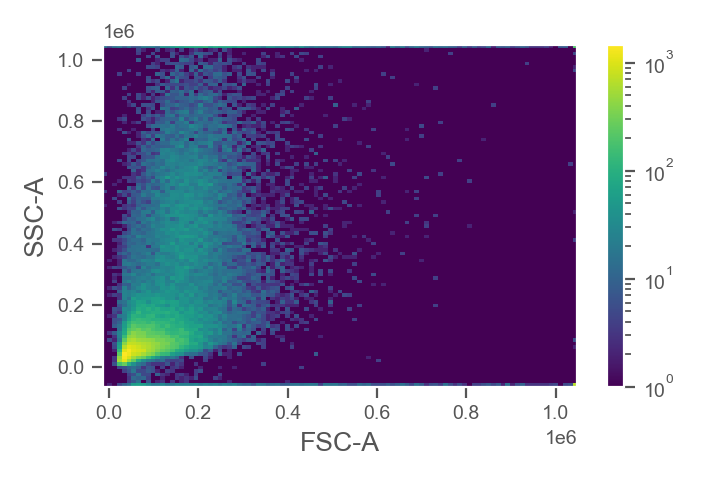

In [10]:
single_gate = flow.PolygonOp(
    name="Single_Cell",
    xchannel="FSC-A",
    ychannel="SSC-A"
)

single_gate.default_view(
    density = True,
    huescale = "log",
    interactive = True
).plot(ex, gridsize = 100)

In [11]:
ex = single_gate.apply(ex)
plt.close()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Gating

### Gating Template
Use the template below for help with gating

```
quad_gate = flow.QuadOp(
    name="",
    xchannel="",
    ychannel="",
)
single_gate = flow.PolygonOp(
    name="",
    xchannel="",
    ychannel="",
    yscale="logicle"
)
___gate = flow.PolygonOp(name="") # placeholder variable
___gate.default_view(
    density = True,
    huescale = "log",
    interactive = True,
    subset = "Single_Cell == True"
) #.plot(ex_single, gridsize=100)
ex_single_gated = ___gate.apply(ex_single)
plt.close()
```

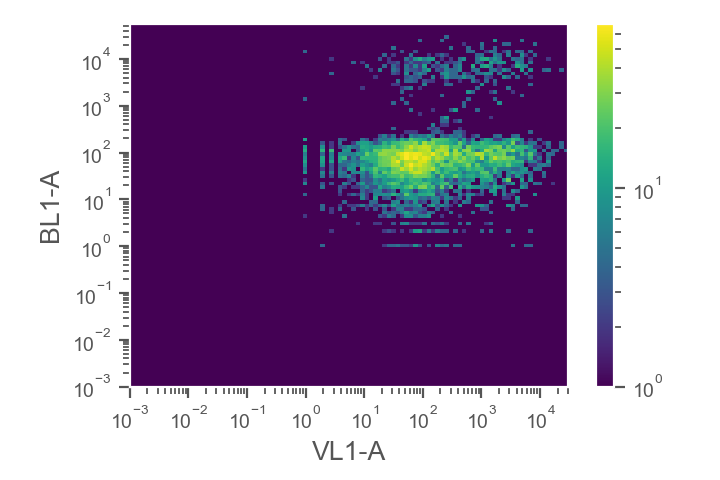

In [12]:
quad_gate = flow.QuadOp(
    name="d_pos",
    xchannel="VL1-A",
    ychannel="BL1-A",
    # xscale="logicle",
    # yscale="logicle"
)

quad_gate.default_view(
    density = True,
    huescale = "log",
    interactive = True,
    subset = "Single_Cell == True",
    xscale="log", yscale="log"
).plot(ex, gridsize=100)

In [13]:
ex = quad_gate.apply(ex)
plt.close()

In [24]:
ex.data.to_csv(os.path.join(DATA_DIR, "processed_data.csv"))

plot_data = ex.data[ex.data["Single_Cell"]==True]

order = ['dCas9-ZIM3', 'H3t-D3L-dCas9', 'H3t-D3L-dCas9-KOX1', 'H3t-KOX1-D3L-dCas9']
order_no_krab = ['H3t-D3L-dCas9', 'H3t-D3L-dCas9-KOX1', 'H3t-KOX1-D3L-dCas9']

channel_labels = {
    f"{BLUE_CHANNEL_NAME} ({BLUE_CHANNEL_TAG})": "VL1-A",
    f"{GREEN_CHANNEL_NAME} ({GREEN_CHANNEL_TAG})": "BL1-A",
    f"{RED_CHANNEL_NAME} ({RED_CHANNEL_TAG})": "RL1-A",
    f"{YELLOW_CHANNEL_NAME} ({YELLOW_CHANNEL_TAG})": "YL1-A"
}

channel_cmaps = {
    f"{BLUE_CHANNEL_NAME} ({BLUE_CHANNEL_TAG})": black_blue_pastel_palette,
    f"{GREEN_CHANNEL_NAME} ({GREEN_CHANNEL_TAG})": black_green_pastel_palette,
    f"{RED_CHANNEL_NAME} ({RED_CHANNEL_TAG})": black_red_pastel_palette,
    f"{YELLOW_CHANNEL_NAME} ({YELLOW_CHANNEL_TAG})": black_yellow_pastel_palette
}

FOCUS_CHANNEL_LABEL = list(channel_labels.keys())[list(channel_labels.values()).index(FOCUS_CHANNEL)]

## Graphing

In [15]:
%matplotlib inline

/Users/alexandresathler/miniconda3/envs/singlecell/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/Users/alexandresathler/miniconda3/envs/singlecell/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
/Users/alexandresathler/Library/CloudStorage/Box-Box/ARS_Working/Analysis/flow_analysis_tools/_flow_violin.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/alexandresathler/miniconda3/envs/singlecell/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/Users/alexandresathler/miniconda3/envs/singlecell/lib/python3.12/site-packages/pandas/core/arraylike.py:399: Run

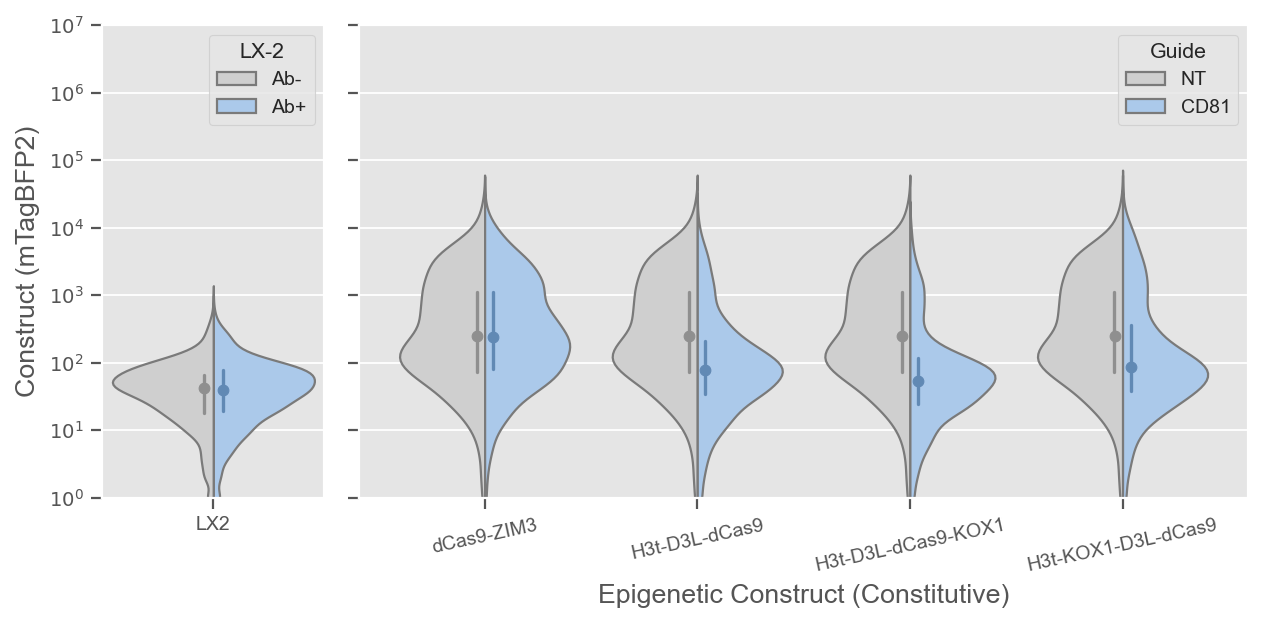

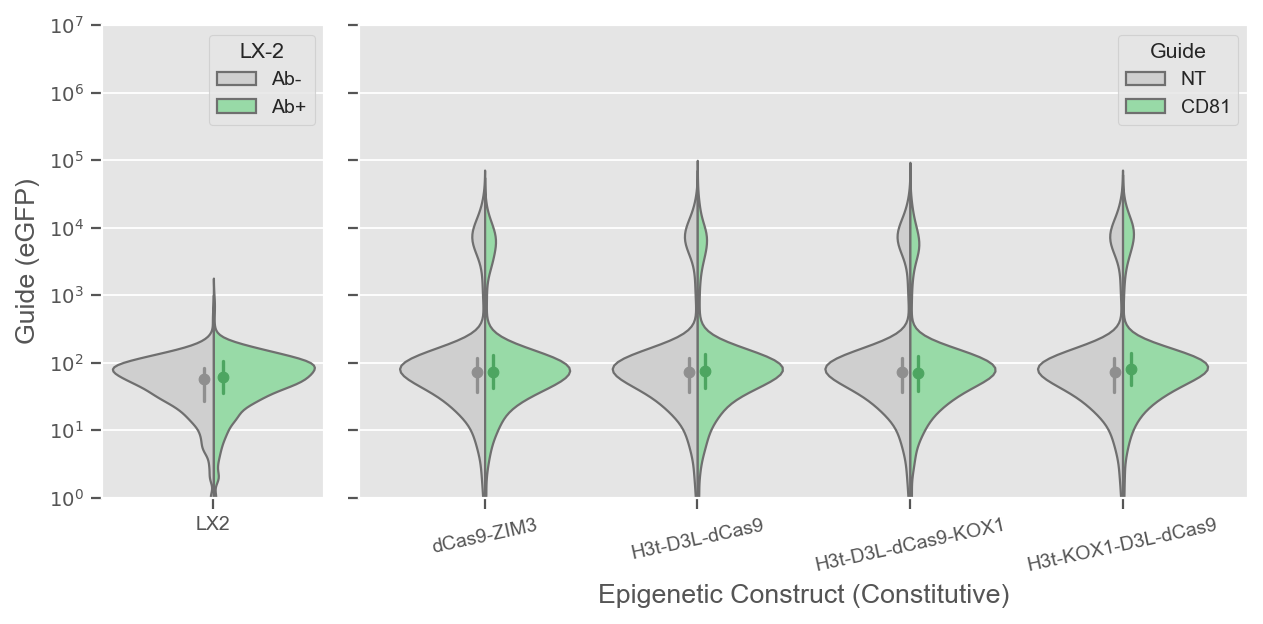

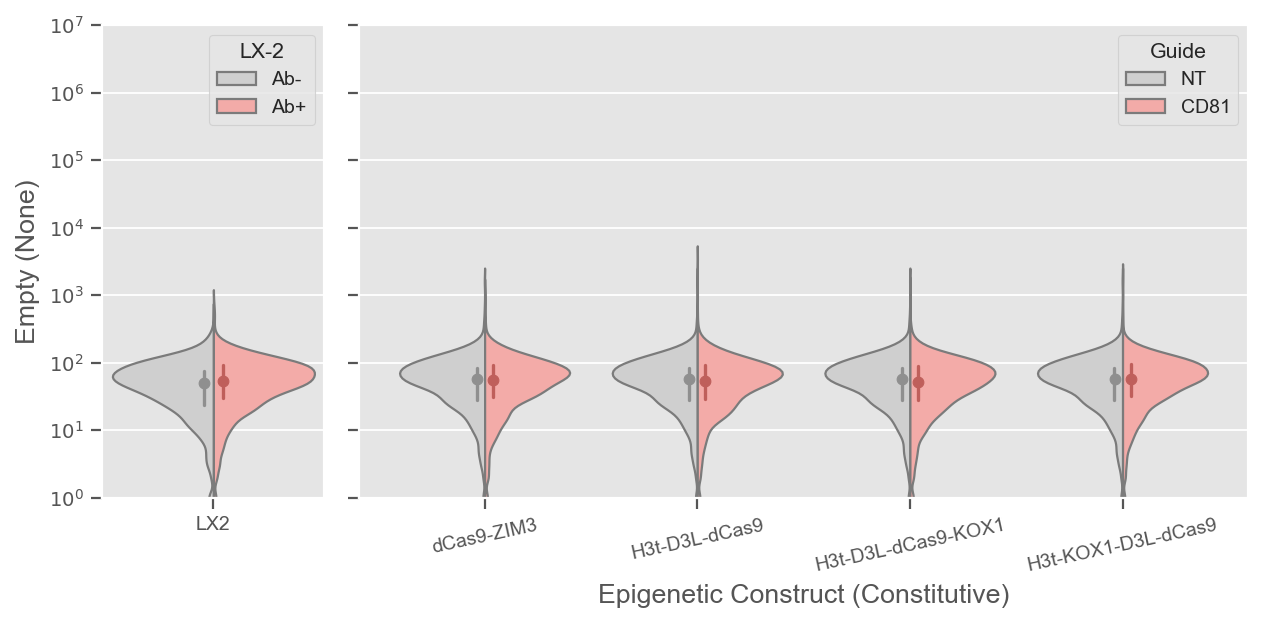

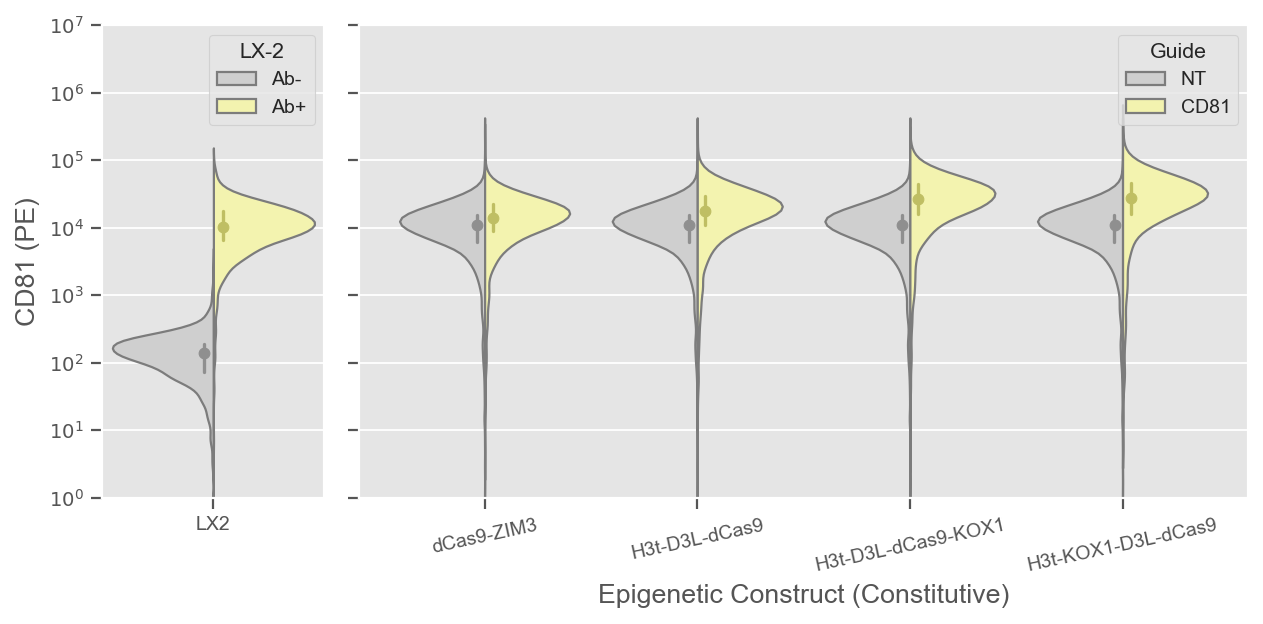

In [27]:
for fluor, flow_channel in channel_labels.items():
    # See: https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_hist.html#id1
    fig, axs = plt.subplot_mosaic(
        [
            ["Mock", "Construct"]
        ],
        figsize=(8,4),
        width_ratios=(1,4),
        sharey=True
        # layout="consrained"
    )

    flow_violin(
        data=plot_data.loc[(plot_data["Construct"] == "LX2")],
        x="Construct",
        y=flow_channel,
        hue="Guide",
        palette=channel_cmaps[fluor],
        split=True,
        log_y_axis=True,
        hue_order=["Ab-", "Ab+"],
        order=["LX2"],
        ylabel=fluor,
        xlabel="",
        density_norm='width',
        ylim=YLIMITS,
        ax=axs['Mock']
    )

    flow_violin(
        data=plot_data.loc[(plot_data["Construct"] != "LX2") & (plot_data["Construct"] != "Unstained")],
        x="Construct",
        y=flow_channel,
        hue="Guide",
        palette=channel_cmaps[fluor],
        order=order,
        split=True,
        log_y_axis=True,
        xlabel="Epigenetic Construct (Constitutive)",
        hue_order=["NT", "CD81"],
        legend_labels=["NT", "CD81"],
        ylim=YLIMITS,
        density_norm='width',
        ax=axs['Construct']
    )

    axs['Mock'].legend(title="LX-2", loc="upper right")
    axs['Construct'].legend(title="Guide", loc="upper right")
    axs['Construct'].set_xticklabels(axs['Construct'].get_xticklabels(), rotation=12.25)
    plt.savefig(os.path.join(DATA_DIR, f"{fluor}.png"))

/Users/alexandresathler/miniconda3/envs/singlecell/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/Users/alexandresathler/miniconda3/envs/singlecell/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
/Users/alexandresathler/Library/CloudStorage/Box-Box/ARS_Working/Analysis/flow_analysis_tools/_flow_violin.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/alexandresathler/miniconda3/envs/singlecell/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
/Users/alexandresathler/Library/CloudStorage/Box-Box/ARS_Working/Analysis/flow_analysis_tools/_flow_violin.py:32: 

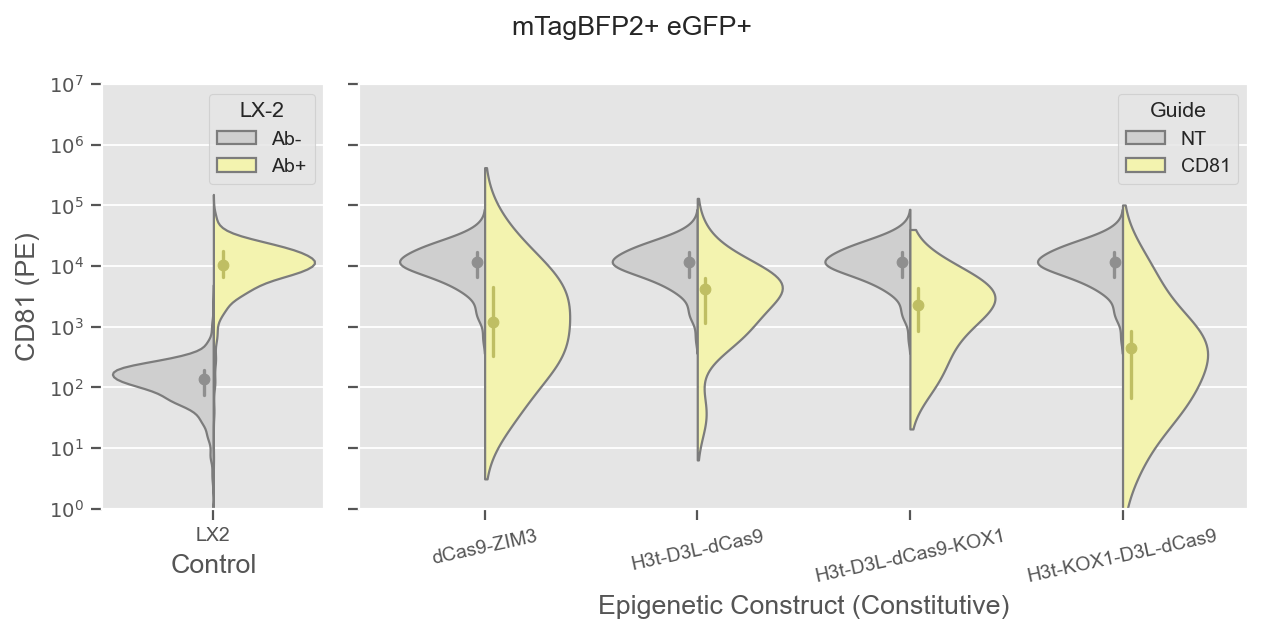

In [28]:
# See: https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_hist.html#id1
fig, axs = plt.subplot_mosaic(
    [
        ["Mock", "Construct"]
    ],
    figsize=(8,4),
    width_ratios=(1,4),
    sharey=True
    # layout="consrained"
)

flow_violin(
    data=plot_data[(plot_data["Construct"] == "LX2")],
    x="Construct",
    y=FOCUS_CHANNEL,
    hue="Guide",
    palette=channel_cmaps[FOCUS_CHANNEL_LABEL],
    # order=list(CONSTRUCT_NAMES),
    split=True,
    log_y_axis=True,
    hue_order=["Ab-", "Ab+"],
    order=["LX2"],
    ylabel=FOCUS_CHANNEL_LABEL,
    xlabel="Control",
    ylim=YLIMITS,
    ax=axs['Mock']
)

flow_violin(
    data=plot_data[(plot_data["d_pos"] == "d_pos_2") & (plot_data["Construct"] != "LX-2")],
    x="Construct",
    y=FOCUS_CHANNEL,
    hue="Guide",
    palette=channel_cmaps[FOCUS_CHANNEL_LABEL],
    order=order,
    split=True,
    log_y_axis=True,
    xlabel="Epigenetic Construct (Constitutive)",
        hue_order=["NT", "CD81"],
        legend_labels=["NT", "CD81"],
    ylim=YLIMITS,
    density_norm='width',
    ax=axs['Construct']
)
axs['Mock'].legend(title="LX-2", loc="upper right")
axs['Construct'].legend(title="Guide", loc="upper right")
axs['Construct'].set_xticklabels(axs['Construct'].get_xticklabels(), rotation=12.25)
fig.suptitle(f"{BLUE_CHANNEL_TAG}+ {GREEN_CHANNEL_TAG}+")
plt.savefig(os.path.join(DATA_DIR, f"{FOCUS_CHANNEL}_construct_and_guide_only.png"))